<a href="https://colab.research.google.com/github/Lelytameyda29rpl/PCVK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **F. TUGAS PRAKTIKUM**

**1. Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.**

Mounted at /content/drive
 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


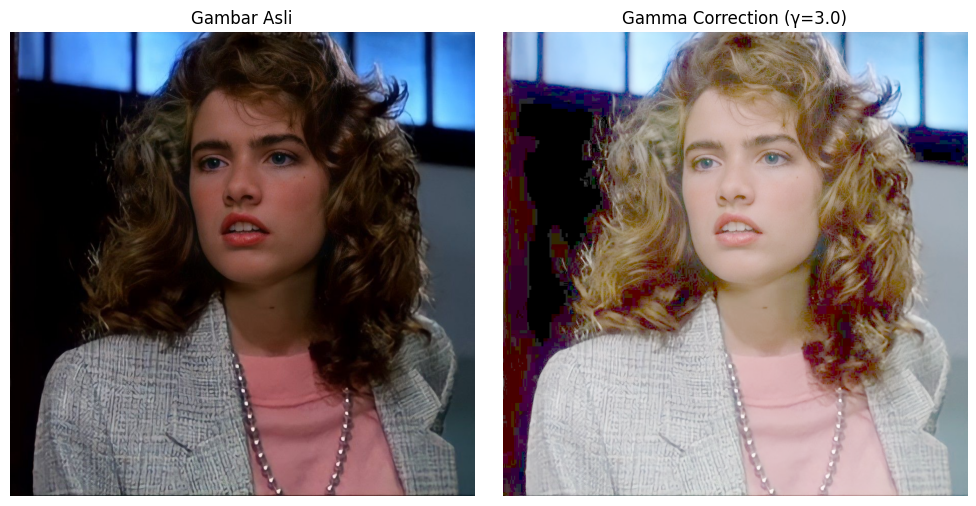

In [1]:
import cv2               # Library untuk pengolahan citra
import numpy as np      # Library untuk operasi matematika array
import matplotlib.pyplot as plt  # Library untuk plotting gambar
from google.colab import drive   # Library untuk mengakses Google Drive di Google Colab

# Mount Google Drive agar dapat membaca file dari Drive
drive.mount('/content/drive')

print(' Gamma Correction pada citra ')
print('----------------------------------')

# Input nilai gamma dari pengguna
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:  # Jika input bukan angka
    print('Error, not a number')
    exit()

# Path lokasi gambar di Google Drive
img_path = '/content/drive/MyDrive/PCVK/JS5/Images/female.jpg'

# Membaca gambar menggunakan OpenCV
img = cv2.imread(img_path)
if img is None:  # Mengecek apakah gambar berhasil dibaca
    print("Gambar tidak ditemukan!")
    print("Pastikan path sudah benar:", img_path)
    exit()

# Normalisasi nilai piksel menjadi rentang [0, 1]
# Supaya perhitungan gamma lebih tepat
img_normalized = img / 255.0

# Melakukan Gamma Correction
# Rumus: output = input^(1/gamma)
gamma_corrected = np.power(img_normalized, 1.0 / gamma)

# Mengubah kembali ke rentang [0, 255] untuk ditampilkan
gamma_corrected = np.uint8(gamma_corrected * 255)

# Menampilkan gambar asli dan hasil gamma correction
plt.figure(figsize=(10, 5))  # Ukuran figure

# Menampilkan gambar asli
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Mengubah dari BGR ke RGB
plt.title('Gambar Asli')
plt.axis('off')  # Mematikan axis

# Menampilkan gambar hasil gamma correction
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB))
plt.title(f'Gamma Correction (γ={gamma})')
plt.axis('off')

plt.tight_layout()  # Mengatur layout agar rapi
plt.show()  # Menampilkan gambar

**1. Jika γ>1 (Contoh: γ=3.0)**

- Hasil: Citra akan terlihat lebih gelap (kontras berkurang di area terang).

**Penjelasan:**

- Ketika γ>1 (misalnya γ=3.0), eksponen 1/γ akan bernilai kurang dari 1 (misalnya 1/3 ≈0.33).

- Kurva transformasi akan melengkung ke atas, mendekati sumbu vertikal.

- Nilai intensitas piksel rendah (area gelap) akan dipetakan ke nilai yang jauh lebih rendah, sementara nilai intensitas piksel tinggi (area terang) akan berubah relatif sedikit.

- Secara visual, rentang warna gelap akan ditekan (dikuatkan), dan detail di area gelap mungkin hilang atau semakin hitam.